breezy-darkness-78
winter-butterfly-80
firm-water-77
vocal-plant-78
devout-hill-74
twilight-meadow-74
wandering-brook-74
hopeful-lion-73
tough-leaf-71
fearless-music-71
celestial-bird-170
resilient-durian-169
comfy-bee-166
glowing-grass-163
efficient-snowball-163
silver-lion-165
lyric-dream-166
good-aardvark-166
cosmic-pine-162
copper-paper-161
fast-deluge-160
gallant-sky-159
resilient-capybara-158
glorious-shape-156
polar-wood-156
bright-flower-155
sage-serenity-152
wandering-aardvark-154
visionary-surf-151
ethereal-lake-152
balmy-darkness-139
glamorous-glade-140
glorious-universe-120
easy-valley-126
glowing-paper-124
woven-sponge-103
soft-resonance-112
quiet-sun-103
dutiful-durian-114
usual-donkey-101


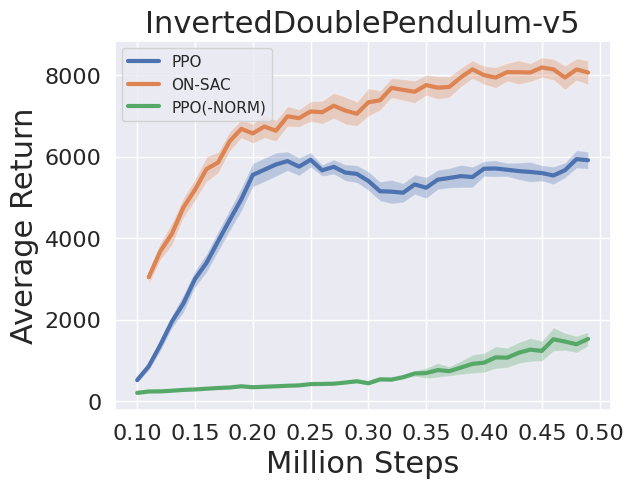

misunderstood-shadow-7
lyric-sunset-11
ethereal-glitter-14
proud-bush-5
clean-tree-7
devoted-fire-15
driven-dream-19
stilted-hill-11
lyric-sky-4
eternal-moon-3
mild-universe-101
icy-lake-99
clean-wind-98
stilted-smoke-97
pretty-water-96
peachy-dust-95
curious-planet-94
stilted-morning-92
peachy-firefly-92
summer-sky-91
faithful-plasma-26
floral-tree-27
silver-eon-30
worthy-moon-33
helpful-shadow-25
dark-shadow-28
devoted-capybara-29
dark-cosmos-25
light-sunset-26
vivid-wave-22


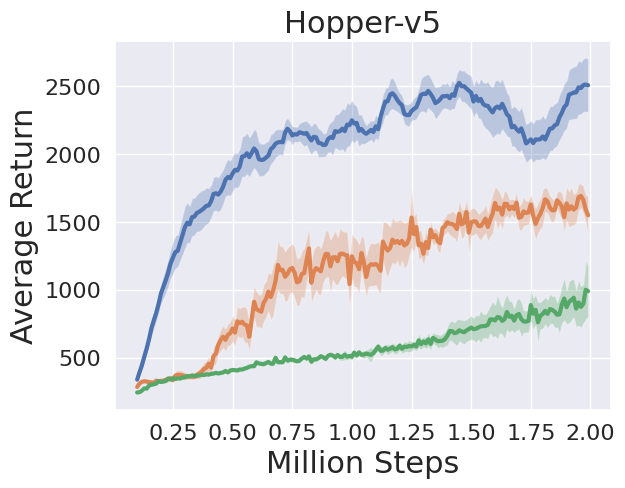

prime-darkness-70
dark-salad-69
bright-shape-67
glowing-smoke-67
exalted-meadow-61
morning-star-61
fallen-mountain-61
rich-violet-61
bumbling-surf-61
confused-gorge-66
lucky-thunder-20
quiet-violet-20
zany-grass-16
fast-lion-16
soft-brook-18
rich-wave-4
cosmic-feather-7
decent-frog-10
crimson-aardvark-8
wild-jazz-1
super-yogurt-119
dazzling-pond-112
woven-aardvark-120
pretty-waterfall-114
devoted-snow-121
glad-serenity-105
tough-plant-105
genial-dawn-125
wandering-dragon-120
faithful-glade-105


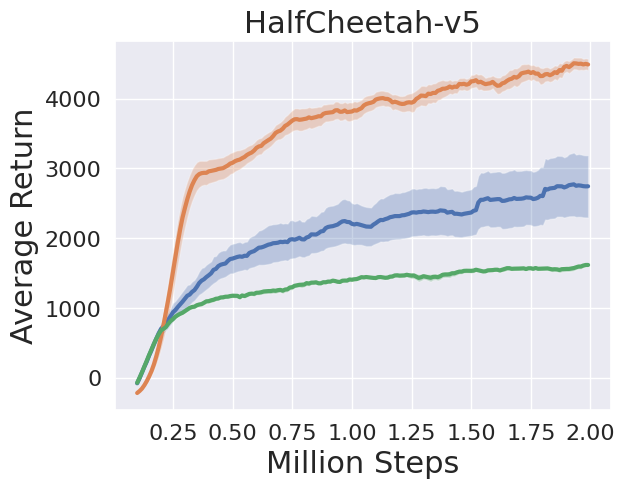

lemon-field-15
daily-meadow-10
silvery-salad-19
gentle-puddle-15
rural-shape-5
trim-glade-15
dutiful-firebrand-8
different-eon-11
pious-snowflake-2
fearless-deluge-1
dulcet-vortex-70
fine-pond-69
rose-plasma-68
firm-field-61
toasty-capybara-64
jumping-blaze-63
summer-firefly-61
azure-vortex-61
sparkling-sponge-61
fresh-bird-63
zesty-wave-39
volcanic-disco-39
snowy-dragon-38
polished-yogurt-32
divine-disco-28
crisp-moon-33
neat-serenity-27
leafy-bee-21
solar-microwave-21
effortless-violet-21


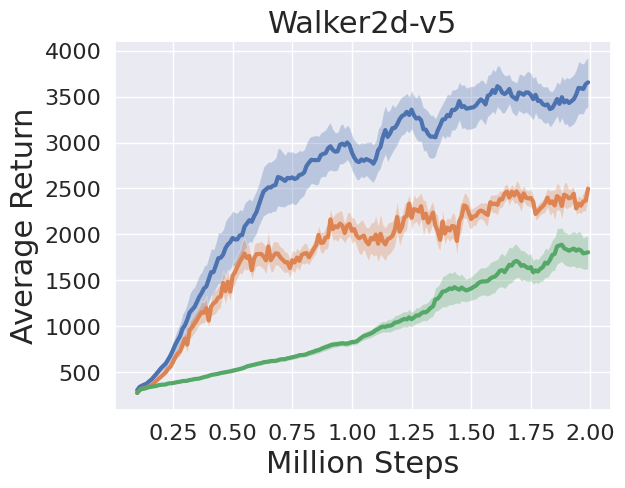

swift-sponge-50
sage-voice-49
cool-oath-48
lunar-firebrand-47
legendary-star-46
vague-spaceship-45
misunderstood-yogurt-44
lyric-aardvark-43
faithful-monkey-41
copper-morning-42
effortless-butterfly-40
fearless-hill-33
young-snowflake-35
generous-snowball-34
fancy-breeze-36
dry-waterfall-36
flowing-water-35
giddy-durian-33
giddy-yogurt-32
eternal-surf-31
treasured-glade-137
silver-cherry-105
feasible-thunder-113
olive-flower-108
charmed-sea-102
dazzling-haze-102
eager-frog-119
silver-lion-104
deft-resonance-120
rural-bird-101


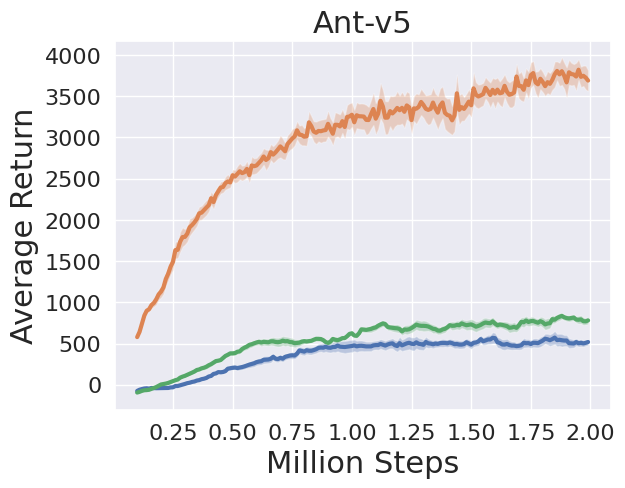

peachy-wood-60
proud-jazz-58
dazzling-disco-59
smart-plasma-57
rich-monkey-54
soft-bird-56
fallen-deluge-52
driven-silence-52
deep-firebrand-51
brisk-surf-55
vocal-universe-149
smart-rain-150
balmy-jazz-124
warm-bush-124
vague-forest-136
distinctive-grass-121
olive-microwave-136
vital-wind-136
bright-galaxy-133
earthy-terrain-136
sandy-pine-137
drawn-monkey-123
wobbly-cloud-105
dry-cosmos-117
helpful-thunder-114
dazzling-bush-114
colorful-oath-136
revived-disco-107
good-violet-101
warm-pond-101


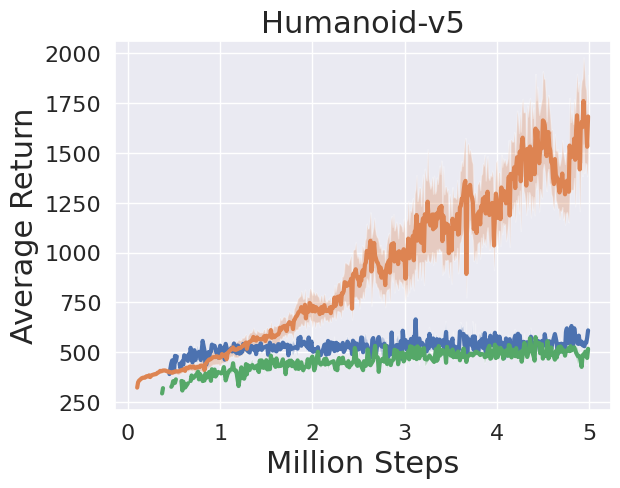

In [1]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "finishitto", "finishitto_995"
runs_99 = api.runs(entity + "/" + project_99)
runs_995 = api.runs(entity + "/" + project_995)

runs = itertools.chain(runs_99,runs_995)
#runs = runs_995

def filter_ppo(run,env_name,normalize_reward):
    return run.config["env_name"] == env_name and run.config["algo_name"] == "ppo" and normalize_reward == run.config["normalize_reward"]


def filter_sac(run,env_name,gamma,discount_actor,use_momentum):
    return run.config["env_name"] == env_name and run.config["algo_name"] == "sac" and gamma == run.config["gamma"] and discount_actor == run.config["discount_actor"] and use_momentum == run.config["use_momentum"]


env_name = "InvertedDoublePendulum-v5"

dc = {"ppo":{"normalize_reward":True},"ppo(-norm)":{"normalize_reward":False},"on-sac":{"gamma":0.995,"discount_actor":True,"use_momentum":False}}
legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","HalfCheetah-v5","Walker2d-v5","Ant-v5","Humanoid-v5"]
max_steps = [5e5,2e6,2e6,2e6,2e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    algo_name = ["ppo","on-sac","ppo(-norm)"]
    #algo_name = ["ppo"]
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if "sac" in algo:

                    if filter_sac(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/episode.return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/episode.return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)

                elif "ppo" in algo :        
                    
                    if filter_ppo(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/episode.return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/episode.return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)
                


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/bench_99/"+env_name+"_benchmark_995.pdf", format="pdf", bbox_inches="tight")  
    plt.show()


In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "finishitto", "finishitto_995"
runs_99 = api.runs(entity + "/" + project_99)
runs_995 = api.runs(entity + "/" + project_995)
runs_onp = api.runs(entity + "/" + "on_policy_data")
runs = itertools.chain(runs_99,runs_995,runs_onp)
#runs = runs_995


def filter_sac(run,env_name,gamma,discount_actor,use_momentum,on_policy_data):

    if "on_policy_data" not in run.config:
        run.config["on_policy_data"] = False
    return run.config["env_name"] == env_name and run.config["algo_name"] == "sac" and gamma == run.config["gamma"] and discount_actor == run.config["discount_actor"] and use_momentum == run.config["use_momentum"] and on_policy_data == run.config["on_policy_data"]


env_name = "InvertedDoublePendulum-v5"

dc = {"on-sac":{"gamma":0.995,"discount_actor":True,"use_momentum":False,"on_policy_data":False},
      "-Discount PG":{"gamma":0.995,"discount_actor":False,"use_momentum":False,"on_policy_data":False},
      "-Off policy":{"gamma":0.995,"discount_actor":True,"use_momentum":False,"on_policy_data":True},
      "+Momentum":{"gamma":0.995,"discount_actor":True,"use_momentum":True,"on_policy_data":False},
      }
legends = [""]

# env_names = ["Hopper-v5","HalfCheetah-v5","Ant-v5"]
# max_steps = [2e6,2e6,2e6]
# legend = [True,False,False]

env_names = ["InvertedDoublePendulum-v5","Hopper-v5","HalfCheetah-v5","Walker2d-v5","Ant-v5","Humanoid-v5"]
max_steps = [5e5,2e6,2e6,2e6,2e6,5e6]
legend = [True,False,False,False,False,False]


for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = ["on-sac","-Discount PG","-Off policy","+Momentum"]
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                

                if filter_sac(run,env_name,**dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/episode.return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/episode.return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_99,runs_995,runs_onp)

    if legend : plt.legend()      
    plt.savefig("./plots/ablations_995/"+env_name+"_ablation_995.pdf", format="pdf", bbox_inches="tight")  
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
items= ["chocolate", "toffees", "cake", "colddrinks", "lays", "biscuit", "frooti"]
sales =[89000, 23000, 98777, 12000, 65000, 11100, 96000]
plt.plot(items,sales,color='m')
a=plt.gca()
plt.xlabel("ITEMS")
plt.ylabel("SALES")
plt.suptitle("SHOP MANGEMENT", fontsize =15)
plt.show()